# Web Scraping and Exploratory Data Analysis of Books

## CodeAlpha Data Analytics Internship

### Project Overview

This project focuses on collecting book data from the Books to Scrape website using Python and web scraping techniques. The collected data is cleaned, structured, explored using Exploratory Data Analysis (EDA), and visualized to identify useful patterns and insights.

### Objectives

- Scrape book information from multiple webpages.
- Collect and organize book titles, prices, ratings, availability, and URLs.
- Clean and validate the collected dataset.
- Perform Exploratory Data Analysis (EDA).
- Analyze relationships between book price and rating.
- Create meaningful data visualizations.
- Generate a structured dataset for further analysis.

## Methodology

The project follows the following workflow:

1. Import required Python libraries.
2. Send HTTP requests to the target website.
3. Parse webpage HTML using BeautifulSoup.
4. Extract book details from multiple pages.
5. Convert the scraped information into a Pandas DataFrame.
6. Clean and validate the collected data.
7. Perform Exploratory Data Analysis.
8. Create visualizations to communicate the findings.
9. Save the processed dataset as a CSV file.

# 1. Import Required Libraries

In [6]:
import requests

url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)

200


# 2. Web Scraping

The Books to Scrape website is accessed using the Requests library. BeautifulSoup is used to parse the HTML content and extract relevant book information from the webpage.

In [7]:
html = response.text

print(html[:1000])

<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
        <meta name="created" content="24th Jun 2016 09:29" />
        <meta name="description" content="" />
        <meta name="viewport" content="width=device-width" />
        <meta name="robots" content="NOARCHIVE,NOCACHE" />

        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
        <!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->

        
            <link rel="shortcut icon" href="static/oscar/favicon.

In [8]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(html, "html.parser")

print(soup.title.text.strip())

All products | Books to Scrape - Sandbox


In [9]:
import requests
from bs4 import BeautifulSoup

url = "https://books.toscrape.com/"

response = requests.get(url)

html = response.text

soup = BeautifulSoup(html, "html.parser")

print(soup.title.text.strip())

All products | Books to Scrape - Sandbox


In [10]:
books = soup.find_all("article", class_="product_pod")

print("Number of books found:", len(books))

Number of books found: 20


In [11]:
first_book = books[0]

print(first_book.prettify())

<article class="product_pod">
 <div class="image_container">
  <a href="catalogue/a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
 </p>
 <h3>
  <a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">
   A Light in the ...
  </a>
 </h3>
 <div class="product_price">
  <p class="price_color">
   Â£51.77
  </p>
  <p class="instock availability">
   <i class="icon-ok">
   </i>
   In stock
  </p>
  <form>
   <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">
    Add to basket
   </button>
  </form>
 </div>
</article>



In [12]:
title = first_book.find("h3").find("a")["title"]

price = first_book.find("p", class_="price_color").text.strip()

rating = first_book.find("p", class_="star-rating")["class"][1]

availability = first_book.find("p", class_="availability").text.strip()

print("Title:", title)
print("Price:", price)
print("Rating:", rating)
print("Availability:", availability)

Title: A Light in the Attic
Price: Â£51.77
Rating: Three
Availability: In stock


# 3. Data Collection

For each book, the following information is collected:

- Title
- Price
- Rating
- Availability
- URL

Data from multiple pages is combined into a single Pandas DataFrame.

In [19]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

base_url = "https://books.toscrape.com/"

all_books = []

for page in range(1, 6):
    url = base_url if page == 1 else f"{base_url}catalogue/page-{page}.html"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.find_all("article", class_="product_pod")

    for book in books:
        title = book.find("h3").find("a")["title"]

        price = book.find("p", class_="price_color").text.strip()
        price = price.replace("Â£", "").replace("£", "")

        rating = book.find("p", class_="star-rating")["class"][1]

        rating_map = {
            "One": 1,
            "Two": 2,
            "Three": 3,
            "Four": 4,
            "Five": 5
        }

        rating = rating_map[rating]

        availability = book.find(
            "p", class_="availability"
        ).text.strip()

        relative_url = book.find("h3").find("a")["href"]
        book_url = base_url + "catalogue/" + relative_url.split("catalogue/")[-1]

        all_books.append({
            "Title": title,
            "Price": float(price),
            "Rating": rating,
            "Availability": availability,
            "URL": book_url
        })

print("Total books collected:", len(all_books))

Total books collected: 100


In [20]:
df = pd.DataFrame(all_books)

print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Rows: 100
Columns: 5


,Title,Price,Rating,Availability,URL
0,A Light in the Attic,51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...


# 4. Data Cleaning and Validation

The scraped data is cleaned and converted into appropriate data types. The dataset is then checked for missing values, duplicate records, and incorrect data types to ensure data quality.

In [16]:
df["Price"] = df["Price"].str.replace("Â£", "", regex=False).astype(float)

print(df.head())

                                   Title  Price Rating Availability
0                   A Light in the Attic  51.77  Three     In stock
1                     Tipping the Velvet  53.74    One     In stock
2                             Soumission  50.10    One     In stock
3                          Sharp Objects  47.82   Four     In stock
4  Sapiens: A Brief History of Humankind  54.23   Five     In stock


In [17]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

print(df.head())

                                   Title  Price  Rating Availability
0                   A Light in the Attic  51.77       3     In stock
1                     Tipping the Velvet  53.74       1     In stock
2                             Soumission  50.10       1     In stock
3                          Sharp Objects  47.82       4     In stock
4  Sapiens: A Brief History of Humankind  54.23       5     In stock


In [21]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Title           0
Price           0
Rating          0
Availability    0
URL             0
dtype: int64


In [22]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [23]:
print(df.dtypes)

Title            object
Price           float64
Rating            int64
Availability     object
URL              object
dtype: object


In [24]:
df.to_csv("CodeAlpha_Book_Web_Scraping.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [25]:
df = pd.read_csv("CodeAlpha_Book_Web_Scraping.csv")

print(df.shape)

(100, 5)


# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure, distribution, and characteristics of the collected book dataset.

In [26]:
print("Dataset Information:")
print()

df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         100 non-null    object 
 1   Price         100 non-null    float64
 2   Rating        100 non-null    int64  
 3   Availability  100 non-null    object 
 4   URL           100 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 4.0+ KB


In [27]:
print("Statistical Summary:")
print()

df.describe()

Statistical Summary:



,Price,Rating
count,100.000000,100.000000
mean,34.560700,2.930000
std,14.638531,1.423149
min,10.160000,1.000000
25%,19.897500,2.000000
50%,34.775000,3.000000
75%,47.967500,4.000000
max,58.110000,5.000000


In [28]:
rating_counts = df["Rating"].value_counts().sort_index()

print(rating_counts)


Rating
1    22
2    19
3    22
4    18
5    19
Name: count, dtype: int64


In [29]:
availability_counts = df["Availability"].value_counts()

print(availability_counts)

Availability
In stock    100
Name: count, dtype: int64


In [30]:
cheapest_book = df.loc[df["Price"].idxmin()]
most_expensive_book = df.loc[df["Price"].idxmax()]

print("Cheapest Book:")
print(cheapest_book[["Title", "Price", "Rating"]])

print("\nMost Expensive Book:")
print(most_expensive_book[["Title", "Price", "Rating"]])

Cheapest Book:
Title     Patience
Price        10.16
Rating           3
Name: 84, dtype: object

Most Expensive Book:
Title     The Death of Humanity: and the Case for Life
Price                                            58.11
Rating                                               4
Name: 68, dtype: object


In [31]:
average_price_by_rating = df.groupby("Rating")["Price"].mean()

print(average_price_by_rating)

Rating
1    35.519545
2    35.909474
3    36.839091
4    33.981667
5    30.012105
Name: Price, dtype: float64


In [32]:
correlation = df["Price"].corr(df["Rating"])

print("Correlation between Price and Rating:", correlation)

Correlation between Price and Rating: -0.12174127007413635


In [33]:
top_10_expensive = df.nlargest(10, "Price")[["Title", "Price", "Rating"]]

print(top_10_expensive.to_string(index=False))

                                                                                                                          Title  Price  Rating
                                                                                   The Death of Humanity: and the Case for Life  58.11       4
                                                                                                 Slow States of Collapse: Poems  57.31       3
                                             Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991  57.25       3
                                                                                                            The Past Never Ends  56.50       4
The Pioneer Woman Cooks: Dinnertime: Comfort Classics, Freezer Food, 16-Minute Meals, and Other Delicious Ways to Solve Supper!  56.41       1
                                                                                                              Masks and Shadows  56.40       2

In [34]:
price_ranges = pd.cut(
    df["Price"],
    bins=[0, 20, 30, 40, 50, 60],
    labels=["£0–20", "£20–30", "£30–40", "£40–50", "£50–60"]
)

print(price_ranges.value_counts().sort_index())

Price
£0–20     26
£20–30    14
£30–40    20
£40–50    17
£50–60    23
Name: count, dtype: int64


# 6. Data Visualization

Visualizations are created using Matplotlib to communicate the patterns and relationships identified during the exploratory analysis.

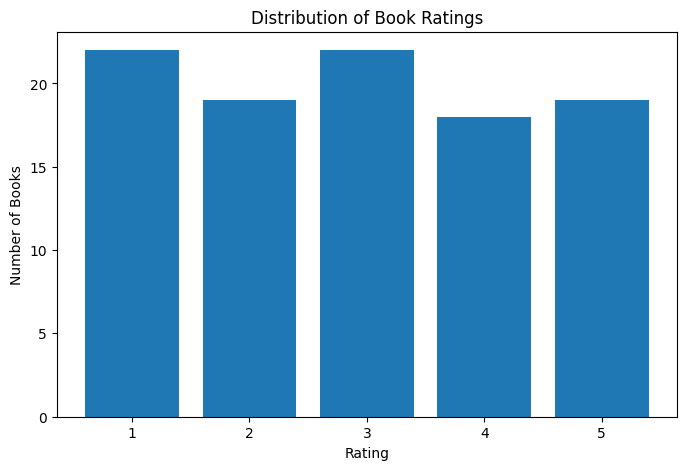

In [35]:
import matplotlib.pyplot as plt

rating_counts = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values)

plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Ratings")

plt.xticks([1, 2, 3, 4, 5])

plt.show()

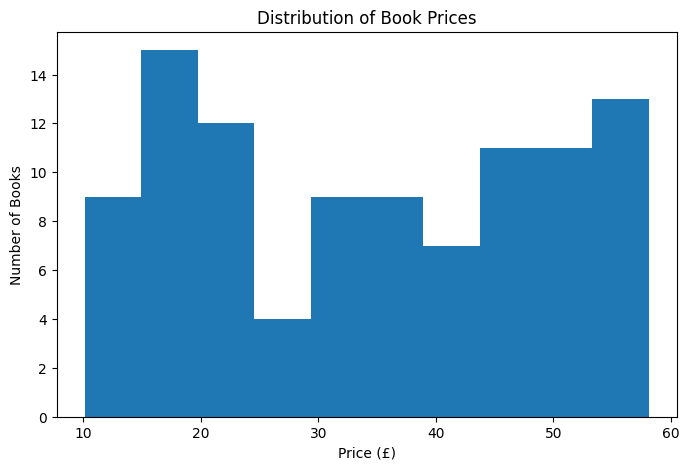

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=10)

plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Prices")

plt.show()

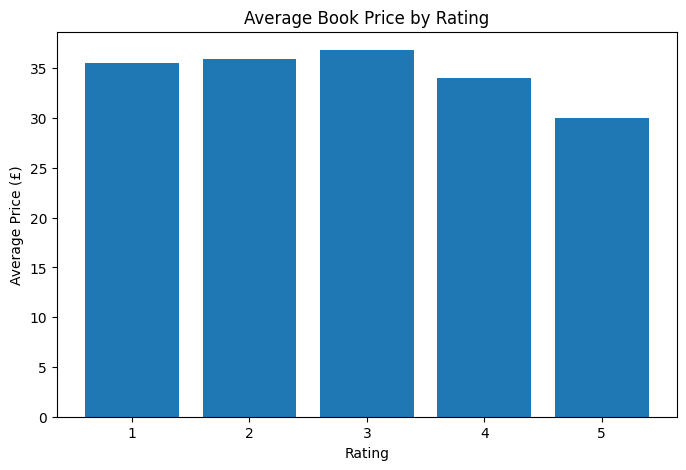

In [37]:
average_price_by_rating = df.groupby("Rating")["Price"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    average_price_by_rating.index,
    average_price_by_rating.values
)

plt.xlabel("Rating")
plt.ylabel("Average Price (£)")
plt.title("Average Book Price by Rating")

plt.xticks([1, 2, 3, 4, 5])

plt.show()

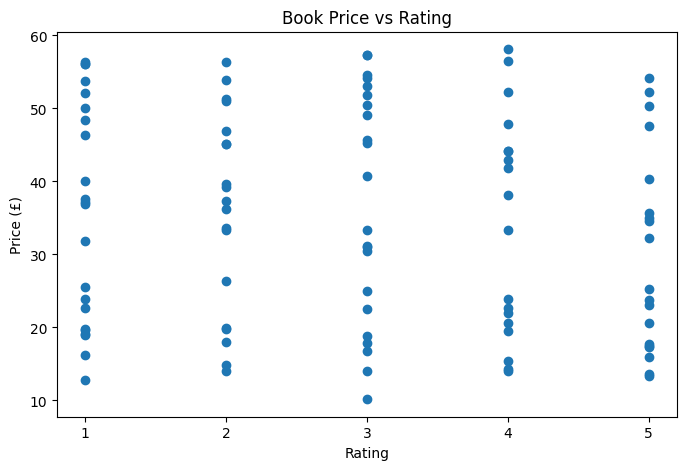

In [38]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Rating"], df["Price"])

plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.title("Book Price vs Rating")

plt.xticks([1, 2, 3, 4, 5])

plt.show()

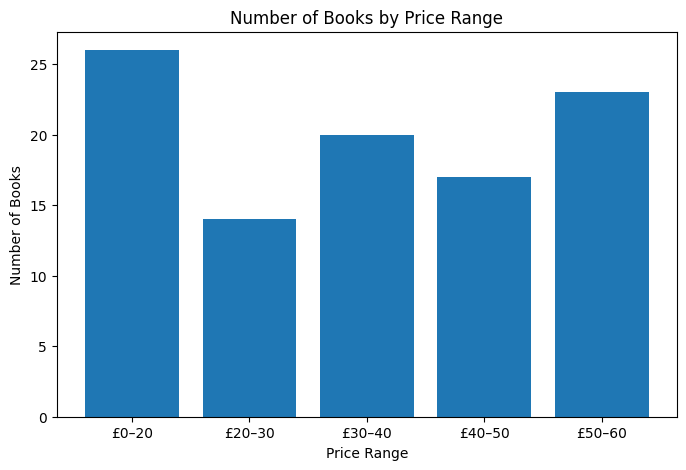

In [39]:
price_ranges = pd.cut(
    df["Price"],
    bins=[0, 20, 30, 40, 50, 60],
    labels=["£0–20", "£20–30", "£30–40", "£40–50", "£50–60"]
)

price_range_counts = price_ranges.value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(price_range_counts.index, price_range_counts.values)

plt.xlabel("Price Range")
plt.ylabel("Number of Books")
plt.title("Number of Books by Price Range")

plt.show()

# 7. Key Findings

- The dataset contains 100 books collected from the Books to Scrape website.
- The average book price is £34.56.
- The average book rating is 2.93 out of 5.
- Book prices range from £10.16 to £58.11.
- The cheapest book is *Patience*, priced at £10.16.
- The most expensive book is *The Death of Humanity: and the Case for Life*, priced at £58.11.
- Ratings are relatively evenly distributed across the dataset.
- All 100 books are listed as in stock.
- The correlation between price and rating is -0.122, indicating a very weak negative linear relationship.
- Five visualizations were created to communicate the major findings.

# 8. Conclusion

This project successfully demonstrates the process of web scraping, data cleaning, exploratory data analysis, and data visualization using Python. Book information was collected from multiple webpages and organized into a structured dataset of 100 records.

The analysis shows considerable variation in book prices, while the relationship between price and rating is very weak. The visualizations provide a clear representation of the distribution and patterns present in the dataset.

Overall, the project demonstrates how raw web data can be transformed into meaningful information through systematic data collection, analysis, and visualization.

In [42]:
from google.colab import files

df.to_csv("CodeAlpha_Book_Web_Scraping.csv", index=False)

files.download("CodeAlpha_Book_Web_Scraping.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>